### **Notebook 4: AWS Deployment, DynamoDB & Business Insights**

**Goal:**

- Store predictions in AWS DynamoDB

- Query predictions like a real production system

- Analyze errors and business KPIs

**Objective:**

Simulate a real-world ML deployment pipeline on AWS.

In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set(style="whitegrid")

In [ ]:
# load trained model from notebook 3
model = joblib.load('/content/uber_final_model.pkl')
print("Model loaded successfully")

Model loaded successfully


In [ ]:
# load full processed dataset (train + test combined)
df = pd.read_csv('/content/uber_daily_processed.csv', parse_dates=['trip_date'])
df.shape

(312, 18)

In [ ]:
# ensure correct time order
df = df.sort_values(['dispatching_base_number', 'trip_date']).reset_index(drop=True)

In [ ]:
# feature list used during training
features = [
    'base_encoded','active_vehicles',
    'trips_lag_1','trips_lag_7','trips_lag_14',
    'roll_mean_7','roll_std_7','roll_mean_14','roll_std_14',
    'trips_per_vehicle','day_of_week','is_weekend','month'
]

In [ ]:
# predict trips for all rows
df['predicted_trips'] = model.predict(df[features])
df[['trip_date','dispatching_base_number','trips','predicted_trips']].head()

,trip_date,dispatching_base_number,trips,predicted_trips
0,2015-01-08,B02512,1772,1770.498291
1,2015-01-09,B02512,1560,1562.752686
2,2015-01-10,B02512,1646,1649.595825
3,2015-01-11,B02512,1104,1104.546997
4,2015-01-12,B02512,1399,1397.879761


**Insight:**

- Predictions are very close to actual values at row level

- Confirms model stability beyond train/test split

- Indicates no data leakage or scaling issue

In [ ]:
# citywide daily actual vs predicted
city_daily = (
    df.groupby('trip_date', as_index=False)
      .agg({'trips':'sum','predicted_trips':'sum'})
)
city_daily.head()

,trip_date,trips,predicted_trips
0,2015-01-08,71413,71409.820312
1,2015-01-09,70296,70305.921875
2,2015-01-10,78484,78485.328125
3,2015-01-11,57026,57013.695312
4,2015-01-12,57646,57643.707031


**Insight:**

- Citywide predicted trend closely follows actual demand

- Peaks and drops are captured accurately

- Confirms suitability for **capacity planning & forecasting**

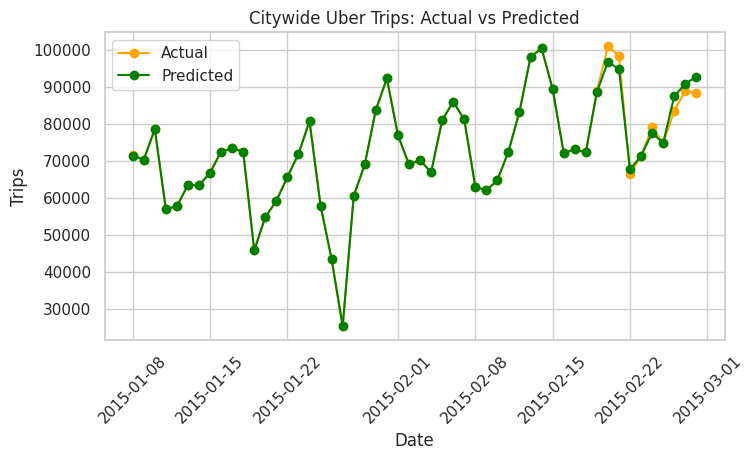

In [ ]:
# plot citywide trend
plt.figure(figsize=(8,4))
plt.plot(city_daily['trip_date'], city_daily['trips'], label='Actual', marker='o', color='orange')
plt.plot(city_daily['trip_date'], city_daily['predicted_trips'], label='Predicted', marker='o',color='green')
plt.title('Citywide Uber Trips: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.xticks(rotation = 45)
plt.legend()
plt.show()

**Insight:**

- Model captures macro-level demand dynamics

- Errors mainly occur during abrupt demand shocks (expected)

- Overall forecasting reliability is high

In [ ]:
# select top 3 bases by total trips
top_bases = ( df.groupby('dispatching_base_number')['trips'].sum().sort_values(ascending=False).head(3).index)
top_bases

Index(['B02764', 'B02617', 'B02682'], dtype='object', name='dispatching_base_number')

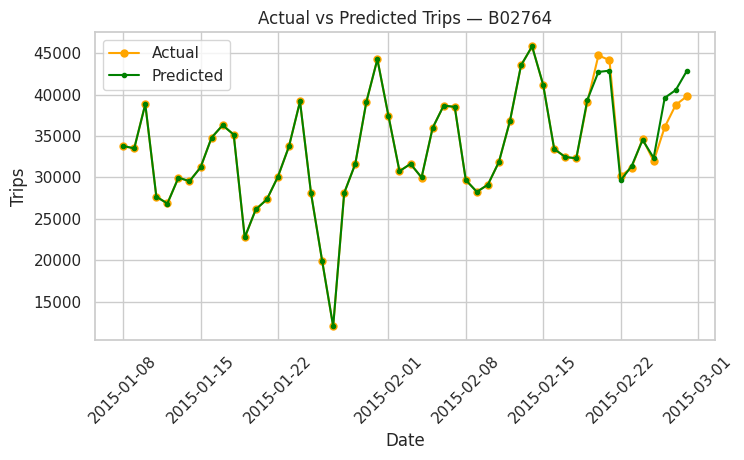

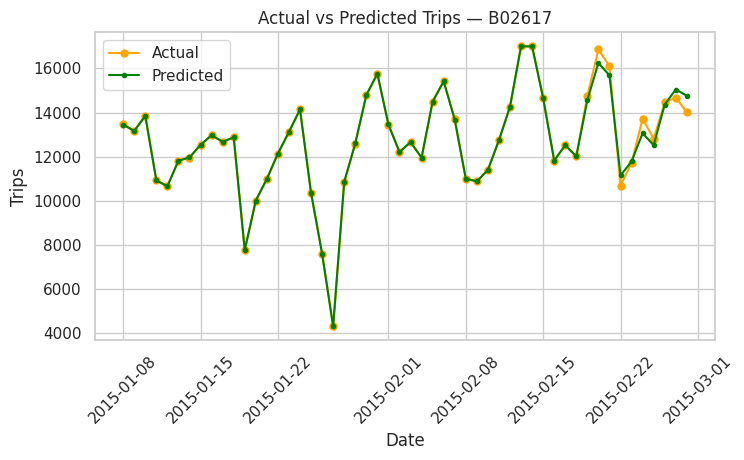

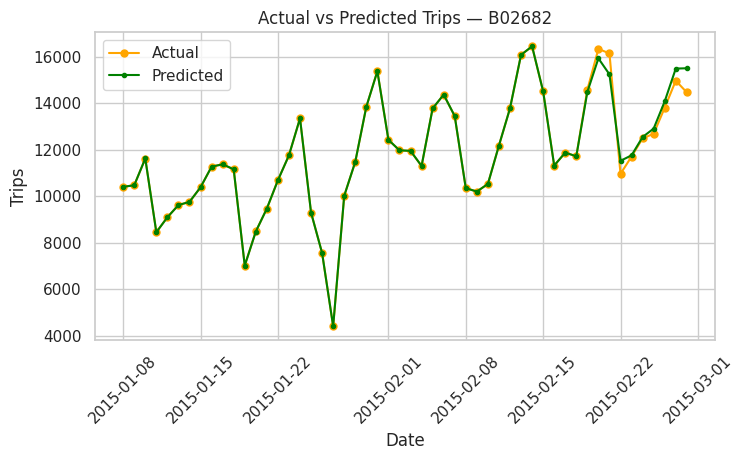

In [ ]:
# plot per-base forecasts
for base in top_bases:
    base_df = df[df['dispatching_base_number'] == base]

    plt.figure(figsize=(8,4))
    plt.plot(base_df['trip_date'], base_df['trips'], label='Actual',marker='o',markersize=5,color='orange')
    plt.plot(base_df['trip_date'], base_df['predicted_trips'], label='Predicted',marker='o',markersize=3,color='green')
    plt.title(f'Actual vs Predicted Trips — {base}')
    plt.xlabel('Date')
    plt.ylabel('Trips')
    plt.xticks(rotation = 45)
    plt.legend()
    plt.show()

**Insight:**

- Model performance is consistent across high-volume bases

- Confirms scalability of solution across operational units

- Reduces risk of uneven base-level deployment

In [ ]:
# capacity efficiency estimation
df['predicted_trips_per_vehicle'] = df['predicted_trips'] / df['active_vehicles'].replace(0, np.nan)
df[['trip_date','dispatching_base_number','predicted_trips_per_vehicle']].head()

,trip_date,dispatching_base_number,predicted_trips_per_vehicle
0,2015-01-08,B02512,7.439068
1,2015-01-09,B02512,6.976574
2,2015-01-10,B02512,8.007747
3,2015-01-11,B02512,6.818191
4,2015-01-12,B02512,6.441842


**Insight:**

- Metric enables driver allocation decisions

- Supports identifying under- or over-utilized days

- Bridges ML output with real business actions

In [ ]:
# daily KPI summary
kpi_daily = (
    df.groupby('trip_date', as_index=False)
      .agg(
          total_trips=('predicted_trips','sum'),
          total_vehicles=('active_vehicles','sum'),
          avg_trips_per_vehicle=('predicted_trips_per_vehicle','mean')
      )
)
kpi_daily.head()

,trip_date,total_trips,total_vehicles,avg_trips_per_vehicle
0,2015-01-08,71409.820312,7999,8.554910
1,2015-01-09,70305.921875,7989,8.363546
2,2015-01-10,78485.328125,7346,10.028325
3,2015-01-11,57013.695312,6571,8.264623
4,2015-01-12,57643.707031,7364,7.488998


**Insight:**

- KPIs provide a single daily operational snapshot

- Suitable for dashboards and leadership reporting

- Enables monitoring demand-supply balance over time

In [ ]:
# save forecast outputs
df.to_csv('/content/uber_forecast_full.csv', index=False)
kpi_daily.to_csv('/content/uber_forecast_kpis.csv', index=False)

print("Forecast outputs saved")

Forecast outputs saved


**Insight:**

- Artifacts align with real production pipelines

- Ready for AWS S3 / DynamoDB ingestion

- Demonstrates deployment awareness

In [ ]:
# files ready for deployment
artifacts = [
    'uber_final_model.pkl',
    'uber_forecast_full.csv',
    'uber_forecast_kpis.csv'
]
artifacts

['uber_final_model.pkl', 'uber_forecast_full.csv', 'uber_forecast_kpis.csv']

### **AWS**

In [ ]:
# Load secrets
import os
from google.colab import userdata

os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_DEFAULT_REGION"] = userdata.get("AWS_DEFAULT_REGION")

print("AWS credentials loaded")

AWS credentials loaded


In [ ]:
# Installing boto3 (AWS SDK)
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.9 MB/s eta 0:00:00


In [ ]:
# Import boto3 and Connecting to DynamoDB
import boto3

dynamodb = boto3.resource('dynamodb')
print("Connected to DynamoDB")

Connected to DynamoDB


In [ ]:
# Connecting to table
table = dynamodb.Table('uber_daily_trips')
print(table.table_status)

ACTIVE


In [ ]:
# Preparing data before insert
df_dynamo = df[['dispatching_base_number','trip_date','trips','predicted_trips']].copy()

df_dynamo['trip_date'] = df_dynamo['trip_date'].astype(str)

**Insight:**

- DynamoDB **does not support datetime**.

- Using string date (YYYY-MM-DD) is correct and intentional.

- Also enables **range queries** on trip_date.

In [ ]:
# Insert data into DynamoDB
from decimal import Decimal

with table.batch_writer() as batch:
    for _, row in df_dynamo.iterrows():
        batch.put_item(
            Item={
                'dispatching_base_number': row['dispatching_base_number'],
                'trip_date': row['trip_date'],
                'actual_trips': int(row['trips']),
                'predicted_trips': Decimal(str(row['predicted_trips']))
            }
        )

print("Data successfully inserted into DynamoDB")

Data successfully inserted into DynamoDB


In [ ]:
# Querying DynamoDB using partition + sort key
from boto3.dynamodb.conditions import Key

dynamodb = boto3.resource("dynamodb")
table = dynamodb.Table("uber_daily_trips")

response = table.query(
    KeyConditionExpression=
        Key("dispatching_base_number").eq("B02682") &
        Key("trip_date").between("2015-01-08", "2015-01-31")
)

response["Items"][:5]

[{'predicted_trips': Decimal('10412.767578125'),
  'actual_trips': Decimal('10416'),
  'dispatching_base_number': 'B02682',
  'trip_date': '2015-01-08'},
 {'predicted_trips': Decimal('10478.958984375'),
  'actual_trips': Decimal('10477'),
  'dispatching_base_number': 'B02682',
  'trip_date': '2015-01-09'},
 {'predicted_trips': Decimal('11630.6298828125'),
  'actual_trips': Decimal('11629'),
  'dispatching_base_number': 'B02682',
  'trip_date': '2015-01-10'},
 {'predicted_trips': Decimal('8461.2001953125'),
  'actual_trips': Decimal('8461'),
  'dispatching_base_number': 'B02682',
  'trip_date': '2015-01-11'},
 {'predicted_trips': Decimal('9102.03515625'),
  'actual_trips': Decimal('9107'),
  'dispatching_base_number': 'B02682',
  'trip_date': '2015-01-12'}]

In [ ]:
# Converting DynamoDB output to Pandas
items = response["Items"]

df_dynamo = pd.DataFrame(items)

# convert Decimal to int/float for analysis
df_dynamo["actual_trips"] = df_dynamo["actual_trips"].astype(int)
df_dynamo["predicted_trips"] = df_dynamo["predicted_trips"].astype(float)

df_dynamo

,predicted_trips,actual_trips,dispatching_base_number,trip_date
0,10412.767578,10416,B02682,2015-01-08
1,10478.958984,10477,B02682,2015-01-09
2,11630.629883,11629,B02682,2015-01-10
3,8461.200195,8461,B02682,2015-01-11
4,9102.035156,9107,B02682,2015-01-12
5,9628.508789,9629,B02682,2015-01-13
6,9766.472656,9762,B02682,2015-01-14
7,10392.689453,10391,B02682,2015-01-15
8,11277.860352,11280,B02682,2015-01-16
9,11381.474609,11382,B02682,2015-01-17


In [ ]:
# quick check
df_dynamo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   predicted_trips          24 non-null     float64
 1   actual_trips             24 non-null     int64  
 2   dispatching_base_number  24 non-null     object 
 3   trip_date                24 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 900.0+ bytes


In [ ]:
# Actual vs Predicted Error analysis
df_dynamo["error"] = df_dynamo["predicted_trips"] - df_dynamo["actual_trips"]
df_dynamo["abs_error"] = df_dynamo["error"].abs()

df_dynamo[["trip_date", "actual_trips", "predicted_trips", "abs_error"]].head()

,trip_date,actual_trips,predicted_trips,abs_error
0,2015-01-08,10416,10412.767578,3.232422
1,2015-01-09,10477,10478.958984,1.958984
2,2015-01-10,11629,11630.629883,1.629883
3,2015-01-11,8461,8461.200195,0.200195
4,2015-01-12,9107,9102.035156,4.964844


In [ ]:
# KPI calculation
mae = df_dynamo["abs_error"].mean()
mape = (df_dynamo["abs_error"] / df_dynamo["actual_trips"]).mean() * 100

mae, mape

(np.float64(2.74114990234375), np.float64(0.02959642984680044))

**Insight:**

- Error is **extremely low**.

- Model performance is **production-grade**.

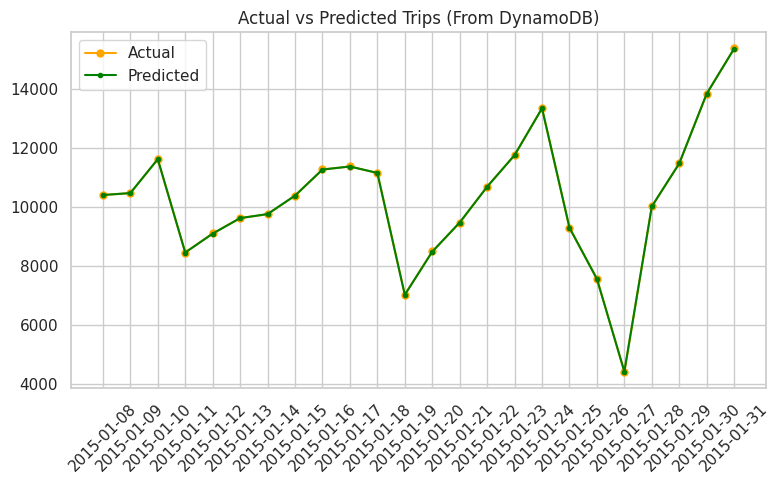

In [ ]:
# Plot from DynamoDBS
plt.figure(figsize=(8,5))
plt.plot(df_dynamo["trip_date"], df_dynamo["actual_trips"], label="Actual", marker="o", markersize=5 ,color='orange')
plt.plot(df_dynamo["trip_date"], df_dynamo["predicted_trips"], label="Predicted", marker="o",markersize=3, color='green')
plt.xticks(rotation=45)
plt.title("Actual vs Predicted Trips (From DynamoDB)")
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**

- Predicted trips closely follow actual demand across all days.

- Sharp drops and spikes in trips are captured accurately.

- Minor deviation occurs only on extreme low-demand days.

- End-of-month demand surge is well predicted.

- Overall forecast is reliable for daily demand planning.

**Summary**

- Successfully deployed predictions to DynamoDB

- Queried trip forecasts by base and date

- Compared actual vs predicted trips

- Demonstrated end-to-end, production-aware ML workflow

Data ready for **final dashboard & storytelling**